<a href="https://colab.research.google.com/github/muajnstu/CAST/blob/main/E1_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from scipy.stats import friedmanchisquare, rankdata
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

RPI


In [ ]:
def parse_mean(val):
    """'0.950±0.031' → 0.950,  'N/A' → np.nan"""
    if val is None:
        return np.nan
    s = str(val).strip()
    if s in ('', 'N/A', 'nan'):
        return np.nan
    if '±' in s:
        return float(s.split('±')[0].strip())
    try:
        return float(s)
    except ValueError:
        return np.nan

CDD

In [ ]:
models  = ['RF', 'ET', 'LR', 'RC', 'NB', 'SGD', 'LDA', 'LGBM', 'Stacking']
metrics = ['Accuracy', 'MCC', 'G-Mean', 'F1-Score']

palette = {
    'RF':       '#1f77b4',
    'ET':       '#1D9E75',
    'LR':       '#ff7f0e',
    'RC':       '#d62728',
    'NB':       '#9467bd',
    'SGD':      '#8c564b',
    'LDA':      '#BA7517',
    'LGBM':     '#2ca02c',
    'Stacking': '#E24B4A',
}
print("Config loaded ✓")

Config loaded ✓


In [ ]:
perception_raw = {
    'RUS': {
        'RF':       ['0.950±0.031','0.928±0.045','0.963±0.023','0.950±0.031'],
        'ET':       ['0.944±0.025','0.918±0.036','0.958±0.019','0.944±0.024'],
        'LR':       ['0.919±0.034','0.882±0.049','0.939±0.026','0.919±0.036'],
        'RC':       ['0.776±0.040','0.687±0.056','0.830±0.031','0.753±0.049'],
        'NB':       ['0.828±0.035','0.748±0.053','0.870±0.027','0.830±0.035'],
        'SGD':      ['0.899±0.042','0.853±0.059','0.923±0.032','0.897±0.042'],
        'LDA':      ['0.913±0.022','0.873±0.031','0.935±0.017','0.913±0.022'],
        'LGBM':     ['0.957±0.027','0.936±0.039','0.968±0.020','0.957±0.027'],
        'Stacking': ['0.955±0.032','0.933±0.047','0.966±0.024','0.955±0.031'],
    },
    'ROS': {
        'RF':       ['0.923±0.042','0.888±0.062','0.942±0.033','0.922±0.045'],
        'ET':       ['0.900±0.058','0.854±0.086','0.925±0.044','0.900±0.058'],
        'LR':       ['0.885±0.073','0.833±0.106','0.912±0.057','0.881±0.079'],
        'RC':       ['0.693±0.096','0.566±0.152','0.764±0.078','0.660±0.107'],
        'NB':       ['0.804±0.080','0.715±0.117','0.850±0.061','0.803±0.080'],
        'SGD':      ['0.766±0.101','0.675±0.131','0.820±0.080','0.739±0.134'],
        'LDA':      ['0.893±0.075','0.844±0.107','0.918±0.058','0.891±0.077'],
        'LGBM':     ['0.896±0.073','0.846±0.108','0.921±0.056','0.894±0.077'],
        'Stacking': ['0.916±0.054','0.876±0.080','0.936±0.041','0.914±0.056'],
    },
    'SMOTE': {
        'RF':       ['0.942±0.038','0.915±0.056','0.957±0.029','0.942±0.038'],
        'ET':       ['0.938±0.024','0.909±0.036','0.953±0.018','0.938±0.024'],
        'LR':       ['0.905±0.037','0.861±0.052','0.928±0.028','0.904±0.037'],
        'RC':       ['0.772±0.048','0.678±0.067','0.827±0.037','0.751±0.058'],
        'NB':       ['0.824±0.023','0.743±0.033','0.867±0.017','0.826±0.023'],
        'SGD':      ['0.861±0.047','0.801±0.065','0.895±0.035','0.856±0.052'],
        'LDA':      ['0.911±0.026','0.870±0.037','0.933±0.019','0.911±0.026'],
        'LGBM':     ['0.942±0.038','0.915±0.056','0.957±0.029','0.942±0.038'],
        'Stacking': ['0.948±0.031','0.924±0.046','0.961±0.023','0.948±0.031'],
    },
    'B-SMOTE': {
        'RF':       ['0.936±0.042','0.905±0.062','0.952±0.032','0.936±0.042'],
        'ET':       ['0.936±0.029','0.906±0.041','0.952±0.022','0.936±0.029'],
        'LR':       ['0.911±0.042','0.869±0.060','0.933±0.032','0.911±0.042'],
        'RC':       ['0.766±0.052','0.666±0.074','0.822±0.040','0.746±0.063'],
        'NB':       ['0.828±0.047','0.745±0.071','0.870±0.036','0.829±0.047'],
        'SGD':      ['0.870±0.050','0.818±0.064','0.902±0.037','0.865±0.054'],
        'LDA':      ['0.915±0.025','0.876±0.035','0.936±0.019','0.915±0.026'],
        'LGBM':     ['0.938±0.029','0.909±0.043','0.953±0.022','0.938±0.029'],
        'Stacking': ['0.944±0.032','0.918±0.048','0.958±0.024','0.944±0.032'],
    },
    'TomekLinks': {
        'RF':       ['0.940±0.026','0.911±0.040','0.951±0.023','0.941±0.027'],
        'ET':       ['0.922±0.042','0.884±0.062','0.939±0.035','0.922±0.044'],
        'LR':       ['0.881±0.047','0.823±0.070','0.906±0.035','0.881±0.046'],
        'RC':       ['0.715±0.057','0.579±0.081','0.785±0.039','0.705±0.061'],
        'NB':       ['0.811±0.051','0.713±0.076','0.853±0.038','0.809±0.052'],
        'SGD':      ['0.821±0.062','0.745±0.084','0.863±0.045','0.818±0.073'],
        'LDA':      ['0.899±0.029','0.849±0.042','0.920±0.024','0.901±0.029'],
        'LGBM':     ['0.935±0.031','0.905±0.046','0.951±0.025','0.935±0.033'],
        'Stacking': ['0.933±0.045','0.899±0.070','0.947±0.039','0.930±0.050'],
    },
}
print("Perception data loaded ✓")

Perception data loaded ✓


HeatMap


In [ ]:
expectation_raw = {
    'RUS': {
        'RF':       ['0.994±0.005','0.991±0.008','0.995±0.004','0.994±0.005'],
        'ET':       ['0.999±0.003','0.998±0.005','0.999±0.002','0.999±0.003'],
        'LR':       ['0.982±0.017','0.974±0.026','0.987±0.013','0.982±0.017'],
        'RC':       ['0.828±0.029','0.754±0.045','0.870±0.022','0.817±0.031'],
        'NB':       ['0.873±0.035','0.813±0.052','0.904±0.027','0.874±0.034'],
        'SGD':      ['0.959±0.041','0.942±0.056','0.969±0.031','0.958±0.042'],
        'LDA':      ['0.962±0.011','0.944±0.016','0.972±0.008','0.962±0.011'],
        'LGBM':     ['0.992±0.004','0.988±0.006','0.994±0.003','0.992±0.004'],
        'Stacking': ['0.999±0.003','0.998±0.005','0.999±0.002','0.999±0.003'],
    },
    'ROS': {
        'RF':       ['0.900±0.078','0.862±0.110','0.924±0.059','0.899±0.077'],
        'ET':       ['0.922±0.087','0.892±0.122','0.941±0.066','0.917±0.094'],
        'LR':       ['0.844±0.113','0.776±0.174','0.882±0.087','0.843±0.113'],
        'RC':       ['0.700±0.158','0.576±0.244','0.769±0.126','0.680±0.162'],
        'NB':       ['0.800±0.120','0.725±0.173','0.848±0.093','0.789±0.138'],
        'SGD':      ['0.744±0.165','0.653±0.237','0.804±0.127','0.693±0.203'],
        'LDA':      ['0.689±0.185','0.552±0.274','0.760±0.146','0.669±0.200'],
        'LGBM':     ['0.911±0.083','0.884±0.105','0.933±0.063','0.904±0.093'],
        'Stacking': ['0.933±0.074','0.906±0.107','0.950±0.056','0.932±0.074'],
    },
    'SMOTE': {
        'RF':       ['0.988±0.006','0.983±0.008','0.991±0.004','0.988±0.006'],
        'ET':       ['0.992±0.010','0.988±0.015','0.994±0.008','0.992±0.010'],
        'LR':       ['0.979±0.016','0.969±0.024','0.984±0.012','0.979±0.016'],
        'RC':       ['0.910±0.029','0.869±0.041','0.932±0.022','0.907±0.032'],
        'NB':       ['0.926±0.023','0.891±0.033','0.944±0.017','0.926±0.022'],
        'SGD':      ['0.954±0.028','0.932±0.040','0.965±0.021','0.954±0.028'],
        'LDA':      ['0.979±0.016','0.969±0.023','0.984±0.012','0.979±0.016'],
        'LGBM':     ['0.983±0.008','0.975±0.013','0.987±0.006','0.983±0.008'],
        'Stacking': ['0.993±0.008','0.989±0.012','0.994±0.006','0.993±0.008'],
    },
    'B-SMOTE': {
        'RF':       ['0.990±0.007','0.984±0.010','0.992±0.005','0.990±0.007'],
        'ET':       ['0.992±0.010','0.988±0.015','0.994±0.008','0.992±0.010'],
        'LR':       ['0.981±0.010','0.972±0.015','0.986±0.008','0.981±0.010'],
        'RC':       ['0.922±0.025','0.886±0.037','0.941±0.019','0.922±0.025'],
        'NB':       ['0.932±0.027','0.900±0.040','0.949±0.020','0.932±0.027'],
        'SGD':      ['0.940±0.035','0.914±0.046','0.955±0.026','0.939±0.038'],
        'LDA':      ['0.975±0.012','0.963±0.017','0.981±0.009','0.975±0.012'],
        'LGBM':     ['0.979±0.009','0.969±0.014','0.984±0.007','0.979±0.009'],
        'Stacking': ['0.992±0.010','0.988±0.015','0.994±0.008','0.992±0.010'],
    },
    'TomekLinks': {
        'RF':       ['0.955±0.031','0.863±0.101','0.909±0.057','0.908±0.075'],
        'ET':       ['0.955±0.029','0.863±0.096','0.910±0.058','0.899±0.070'],
        'LR':       ['0.947±0.031','0.845±0.096','0.904±0.070','0.879±0.084'],
        'RC':       ['0.879±0.044','0.629±0.137','0.765±0.080','0.656±0.127'],
        'NB':       ['0.854±0.066','0.675±0.125','0.878±0.074','0.761±0.113'],
        'SGD':      ['0.894±0.025','0.691±0.067','0.810±0.052','0.739±0.066'],
        'LDA':      ['0.955±0.035','0.861±0.115','0.909±0.081','0.903±0.101'],
        'LGBM':     ['0.940±0.028','0.821±0.085','0.890±0.049','0.856±0.068'],
        'Stacking': ['0.952±0.032','0.858±0.105','0.914±0.059','0.887±0.070'],
    },
}
print("Expectation data loaded ✓")

Expectation data loaded ✓


In [ ]:
gap_raw = {
    'ROS': {
        'RF':       ['0.990±0.009','0.986±0.013','0.993±0.007','0.990±0.009'],
        'ET':       ['0.990±0.009','0.986±0.013','0.993±0.007','0.990±0.009'],
        'LR':       ['0.952±0.023','0.931±0.033','0.964±0.018','0.952±0.024'],
        'RC':       ['0.773±0.031','0.684±0.044','0.827±0.024','0.746±0.038'],
        'NB':       ['0.886±0.038','0.832±0.057','0.914±0.029','0.886±0.037'],
        'SGD':      ['0.920±0.036','0.884±0.052','0.940±0.027','0.918±0.037'],
        'LDA':      ['0.928±0.029','0.895±0.041','0.946±0.022','0.927±0.030'],
        'LGBM':     ['0.985±0.007','0.978±0.011','0.989±0.005','0.985±0.007'],
        'Stacking': ['0.992±0.009','0.988±0.013','0.994±0.007','0.992±0.009'],
    },
    'RUS': {
        'RF':       ['0.893±0.109','0.858±0.141','0.915±0.086','0.872±0.141'],
        'ET':       ['0.893±0.100','0.855±0.132','0.915±0.077','0.882±0.108'],
        'LR':       ['0.823±0.114','0.746±0.172','0.863±0.094','0.807±0.137'],
        'RC':       ['0.687±0.162','0.553±0.249','0.760±0.132','0.665±0.177'],
        'NB':       ['0.833±0.160','0.759±0.235','0.871±0.123','0.819±0.173'],
        'SGD':      ['0.687±0.120','0.558±0.172','0.756±0.108','0.648±0.160'],
        'LDA':      ['0.835±0.102','0.761±0.150','0.878±0.077','0.835±0.098'],
        'LGBM':     ['0.902±0.075','0.866±0.102','0.926±0.058','0.897±0.081'],
        'Stacking': ['0.903±0.084','0.870±0.106','0.925±0.063','0.897±0.088'],
    },
    'ADASYN': {
        'RF':       ['0.976±0.015','0.964±0.021','0.982±0.011','0.976±0.015'],
        'ET':       ['0.978±0.014','0.968±0.020','0.984±0.010','0.978±0.014'],
        'LR':       ['0.940±0.017','0.912±0.025','0.955±0.013','0.940±0.018'],
        'RC':       ['0.798±0.036','0.717±0.050','0.847±0.027','0.777±0.043'],
        'NB':       ['0.905±0.025','0.860±0.039','0.928±0.019','0.906±0.025'],
        'SGD':      ['0.898±0.028','0.853±0.039','0.923±0.022','0.895±0.030'],
        'LDA':      ['0.913±0.017','0.874±0.025','0.935±0.013','0.912±0.018'],
        'LGBM':     ['0.969±0.019','0.954±0.028','0.977±0.014','0.969±0.019'],
        'Stacking': ['0.976±0.017','0.964±0.025','0.982±0.013','0.976±0.017'],
    },
    'SMOTE': {
        'RF':       ['0.962±0.013','0.944±0.020','0.971±0.010','0.962±0.013'],
        'ET':       ['0.967±0.015','0.952±0.022','0.975±0.011','0.967±0.015'],
        'LR':       ['0.936±0.026','0.906±0.039','0.952±0.020','0.935±0.027'],
        'RC':       ['0.771±0.031','0.681±0.044','0.827±0.023','0.746±0.038'],
        'NB':       ['0.895±0.030','0.848±0.044','0.921±0.023','0.896±0.030'],
        'SGD':      ['0.914±0.028','0.875±0.040','0.936±0.021','0.913±0.029'],
        'LDA':      ['0.917±0.021','0.878±0.030','0.937±0.016','0.915±0.022'],
        'LGBM':     ['0.962±0.015','0.944±0.022','0.971±0.011','0.962±0.015'],
        'Stacking': ['0.971±0.018','0.958±0.026','0.979±0.013','0.971±0.018'],
    },
    'B-SMOTE': {
        'RF':       ['0.973±0.016','0.960±0.024','0.980±0.012','0.973±0.016'],
        'ET':       ['0.981±0.014','0.972±0.020','0.986±0.010','0.981±0.014'],
        'LR':       ['0.943±0.024','0.917±0.036','0.957±0.019','0.942±0.025'],
        'RC':       ['0.770±0.066','0.670±0.096','0.825±0.051','0.750±0.077'],
        'NB':       ['0.918±0.033','0.881±0.046','0.938±0.025','0.919±0.032'],
        'SGD':      ['0.909±0.048','0.868±0.070','0.931±0.036','0.907±0.049'],
        'LDA':      ['0.936±0.029','0.907±0.042','0.952±0.022','0.935±0.030'],
        'LGBM':     ['0.978±0.018','0.968±0.026','0.984±0.013','0.978±0.018'],
        'Stacking': ['0.981±0.018','0.972±0.026','0.986±0.013','0.981±0.018'],
    },
    'STomek': {
        'RF':       ['0.962±0.013','0.944±0.020','0.971±0.010','0.962±0.013'],
        'ET':       ['0.967±0.015','0.952±0.022','0.975±0.011','0.967±0.015'],
        'LR':       ['0.936±0.026','0.906±0.039','0.952±0.020','0.935±0.027'],
        'RC':       ['0.771±0.031','0.681±0.044','0.827±0.023','0.746±0.038'],
        'NB':       ['0.895±0.030','0.848±0.044','0.921±0.023','0.896±0.030'],
        'SGD':      ['0.914±0.028','0.875±0.040','0.936±0.021','0.913±0.029'],
        'LDA':      ['0.917±0.021','0.878±0.030','0.937±0.016','0.915±0.022'],
        'LGBM':     ['0.962±0.015','0.944±0.022','0.971±0.011','0.962±0.015'],
        'Stacking': ['0.971±0.018','0.958±0.026','0.979±0.013','0.971±0.018'],
    },
    'TomekLinks': {
        'RF':       ['0.936±0.041','0.876±0.080','0.911±0.051','0.908±0.055'],
        'ET':       ['0.936±0.035','0.877±0.069','0.915±0.052','0.910±0.059'],
        'LR':       ['0.905±0.038','0.824±0.067','0.908±0.033','0.889±0.042'],
        'RC':       ['0.781±0.076','0.569±0.155','0.699±0.069','0.557±0.092'],
        'NB':       ['0.900±0.036','0.810±0.070','0.897±0.050','0.858±0.070'],
        'SGD':      ['0.830±0.071','0.699±0.114','0.845±0.074','0.775±0.116'],
        'LDA':      ['0.902±0.038','0.823±0.063','0.912±0.033','0.895±0.039'],
        'LGBM':     ['0.951±0.039','0.907±0.076','0.942±0.049','0.941±0.051'],
        'Stacking': ['0.954±0.034','0.912±0.065','0.942±0.047','0.943±0.047'],
    },
}
print("Gap data loaded ✓")

Gap data loaded ✓


In [ ]:
def plot_heatmap(raw_data, experiment_name):
    balancers = list(raw_data.keys())
    B = len(balancers)
    M = len(models)
    K = len(metrics)

    # shape: (balancers, models, metrics)
    mat = np.full((B, M, K), np.nan)
    for b_i, b in enumerate(balancers):
        for m_i, m in enumerate(models):
            for k_i in range(K):
                mat[b_i, m_i, k_i] = parse_mean(raw_data[b][m][k_i])

    # mean across balancers → (models, metrics)
    mean_mat = np.nanmean(mat, axis=0)

    # column-wise normalise for colour only
    norm_mat = np.zeros_like(mean_mat)
    for k_i in range(K):
        col = mean_mat[:, k_i]
        valid = col[~np.isnan(col)]
        if len(valid) < 2:
            continue
        cmin, cmax = valid.min(), valid.max()
        norm_mat[:, k_i] = (col - cmin) / (cmax - cmin + 1e-12)

    fig, ax = plt.subplots(figsize=(11, 6))
    im = ax.imshow(norm_mat.T, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)

    ax.set_xticks(range(M))
    ax.set_xticklabels(models, fontsize=11, fontweight='bold')
    ax.set_yticks(range(K))
    ax.set_yticklabels(metrics, fontsize=11, fontweight='bold')

    # grid lines
    ax.set_xticks(np.arange(-0.5, M, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, K, 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=2)
    ax.tick_params(which='minor', bottom=False, left=False)

    # cell annotations
    for m_i in range(M):
        for k_i in range(K):
            val = mean_mat[m_i, k_i]
            txt = f'{val:.3f}' if not np.isnan(val) else 'N/A'
            nv  = norm_mat[m_i, k_i]
            clr = 'white' if (nv < 0.25 or nv > 0.82) else 'black'
            ax.text(m_i, k_i, txt, ha='center', va='center',
                    fontsize=9.5, fontweight='bold', color=clr)

    cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label('Normalised score (per metric)', fontsize=10)
    cbar.ax.tick_params(labelsize=9)

    ax.set_title(
        f'Performance Heatmap — {experiment_name}\n'
        f'(Mean across {B} balancers: {", ".join(balancers)})',
        fontsize=12, fontweight='bold', pad=12)

    plt.tight_layout()
    plt.savefig(f'heatmap_{experiment_name}.png', dpi=200, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: heatmap_{experiment_name}.png")

In [ ]:
def plot_rpi(raw_data, experiment_name):
    balancers = list(raw_data.keys())
    B = len(balancers)
    M = len(models)
    # AUROC বাদ → শুধু প্রথম 4 metric
    rpi_metrics = ['Accuracy', 'MCC', 'G-Mean', 'F1-Score']
    K = 4

    style = {
        'Accuracy': dict(color='#85B7EB', edgecolor='#185FA5', linewidth=1.2),
        'MCC':      dict(color='#FFD700', edgecolor='#B8860B', linewidth=1.2),
        'G-Mean':   dict(color='#F0997B', edgecolor='#993C1D', linewidth=1.2),
        'F1-Score': dict(color='#AFA9EC', edgecolor='#534AB7', linewidth=1.2),
    }

    bar_width = 0.20
    x         = np.arange(M)
    offsets   = np.linspace(-(K-1)/2, (K-1)/2, K) * bar_width

    # mean across balancers → (models, 4 metrics)
    mean_mat = np.full((M, K), np.nan)
    for m_i, m in enumerate(models):
        for k_i in range(K):
            vals = [parse_mean(raw_data[b][m][k_i]) for b in balancers]
            valid = [v for v in vals if not np.isnan(v)]
            if valid:
                mean_mat[m_i, k_i] = np.mean(valid)

    # RPI calculation per metric
    rpi_mat = np.zeros((M, K))
    for k_i in range(K):
        col = mean_mat[:, k_i]
        valid = col[~np.isnan(col)]
        min_v = valid.min() if len(valid) > 0 else 0
        for m_i in range(M):
            v = col[m_i]
            rpi_mat[m_i, k_i] = (v - min_v) * 100 if not np.isnan(v) else 0.0

    # plot
    fig, ax = plt.subplots(figsize=(14, 6))

    for k_i, metric in enumerate(rpi_metrics):
        bars = ax.bar(x + offsets[k_i], rpi_mat[:, k_i],
                      width=bar_width, label=metric, **style[metric])
        for bar, m_i in zip(bars, range(M)):
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        h + 0.02,
                        f'{h:.2f}',
                        ha='center', va='bottom',
                        fontsize=6.5, color='#333333', rotation=90)

    legend_handles = [
        mpatches.Patch(label=f'RPI Score ({m})',
                       facecolor=style[m]['color'],
                       edgecolor='black')
        for m in rpi_metrics
    ]

    ax.set_title(f'RPI Scores — {experiment_name}\n(Mean across {B} balancers)',
                 fontsize=13, fontweight='bold', pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_ylabel('RPI Score (%)', fontsize=11)
    ax.tick_params(axis='y', labelsize=10)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(handles=legend_handles, loc='upper center',
              bbox_to_anchor=(0.5, -0.10), ncol=4,
              fontsize=10, frameon=False)

    plt.tight_layout()
    fname = f'rpi_{experiment_name}.png'
    plt.savefig(fname, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {fname}")

In [ ]:
def plot_cd_diagram(raw_data, experiment_name):
    balancers = list(raw_data.keys())
    B = len(balancers)   # number of "datasets"
    M = len(models)
    K = len(metrics)

    # score per (balancer, model) = nanmean of all metrics
    scores = np.full((B, M), np.nan)
    for b_i, b in enumerate(balancers):
        for m_i, m in enumerate(models):
            vals = [parse_mean(raw_data[b][m][k_i]) for k_i in range(K)]
            valid = [v for v in vals if not np.isnan(v)]
            if valid:
                scores[b_i, m_i] = np.mean(valid)

    # rank each balancer row (higher score = rank 1)
    ranks = np.zeros_like(scores)
    for b_i in range(B):
        row = scores[b_i]
        neg = [-v if not np.isnan(v) else 1e9 for v in row]
        ranks[b_i] = rankdata(neg)

    mean_ranks = ranks.mean(axis=0)

    # Friedman test
    stat, p_value = friedmanchisquare(*[ranks[:, j] for j in range(M)])

    # Nemenyi CD (alpha=0.05, k=9 → q_alpha=2.724)
    q_alpha = 2.724
    CD = q_alpha * np.sqrt(M * (M + 1) / (6 * B))

    print(f'\n[{experiment_name}]')
    print(f'  Friedman χ² = {stat:.4f},  p = {p_value:.6f}')
    print(f'  CD = {CD:.4f}  (Nemenyi α=0.05, k={M}, N={B})')

    sorted_idx   = np.argsort(mean_ranks)
    sorted_names = [models[i] for i in sorted_idx]
    sorted_ranks = mean_ranks[sorted_idx]

    # significant pairs
    sig_pairs = set()
    for (i, j) in combinations(range(M), 2):
        if abs(sorted_ranks[i] - sorted_ranks[j]) > CD:
            sig_pairs.add((sorted_names[i], sorted_names[j]))

    # ── figure ────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.set_xlim(0.3, M + 0.7)
    ax.set_ylim(-3.2, 2.5)
    ax.axis('off')

    axis_y = 1.4

    # rank axis
    ax.plot([1, M], [axis_y, axis_y], color='black', lw=2.0)
    for r in range(1, M + 1):
        ax.plot([r, r], [axis_y, axis_y - 0.14], color='black', lw=1.3)
        ax.text(r, axis_y + 0.20, str(r), ha='center', va='bottom',
                fontsize=11, color='black')
    ax.text((1 + M) / 2, axis_y + 0.65,
            'Average Rank  (lower = better)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

    # CD bar (top right)
    cd_right = M + 0.3
    cd_left  = cd_right - CD
    cd_y     = axis_y + 1.20
    ax.plot([cd_left, cd_right], [cd_y, cd_y], color='black', lw=2.0)
    for cx in [cd_left, cd_right]:
        ax.plot([cx, cx], [cd_y - 0.10, cd_y + 0.10], color='black', lw=2.0)
    ax.text((cd_left + cd_right) / 2, cd_y + 0.17,
            f'CD = {CD:.2f}', ha='center', va='bottom', fontsize=11)

    # labels: left half above, right half below axis
    n_left  = M // 2          # 4 labels on left side
    v_step  = 0.58

    for pos, (name, rank) in enumerate(zip(sorted_names, sorted_ranks)):
        color = palette.get(name, '#333333')
        ax.plot(rank, axis_y, 'o', color=color, ms=9, zorder=5)

        if pos < n_left:
            ly = axis_y + 0.60 + (n_left - 1 - pos) * v_step
            ax.plot([rank, rank], [axis_y, ly], color=color,
                    lw=1.1, ls='--', alpha=0.7)
            ax.plot([1.0, rank], [ly, ly], color=color,
                    lw=1.1, ls='--', alpha=0.7)
            ax.text(0.28, ly, f'{name} ({rank:.2f})',
                    ha='right', va='center', fontsize=10.5,
                    color=color, fontweight='bold')
        else:
            rpos = pos - n_left
            ly   = axis_y - 0.60 - rpos * v_step
            ax.plot([rank, rank], [axis_y, ly], color=color,
                    lw=1.1, ls='--', alpha=0.7)
            ax.plot([rank, M + 0.1], [ly, ly], color=color,
                    lw=1.1, ls='--', alpha=0.7)
            ax.text(M + 0.22, ly, f'{name} ({rank:.2f})',
                    ha='left', va='center', fontsize=10.5,
                    color=color, fontweight='bold')

    # clique bars (non-significant groups)
    drawn        = []
    clique_base  = axis_y - 0.28
    clique_step  = 0.22

    for i in range(M):
        group = [i]
        for j in range(i + 1, M):
            p1 = (sorted_names[i], sorted_names[j])
            p2 = (sorted_names[j], sorted_names[i])
            if p1 not in sig_pairs and p2 not in sig_pairs:
                group.append(j)
        if len(group) > 1:
            key = tuple(group)
            if key not in drawn:
                drawn.append(key)
                bar_y   = clique_base - len(drawn) * clique_step
                x_start = sorted_ranks[group[0]]
                x_end   = sorted_ranks[group[-1]]
                ax.plot([x_start, x_end], [bar_y, bar_y],
                        color='black', lw=5,
                        solid_capstyle='round', alpha=0.80)

    p_str = 'p < 0.001' if p_value < 0.001 else f'p = {p_value:.4f}'
    ax.set_title(
        f'Critical Difference Diagram — {experiment_name}\n'
        f'Friedman χ² = {stat:.3f},  {p_str}  |  CD = {CD:.3f}  (Nemenyi α = 0.05)',
        fontsize=12, fontweight='bold', pad=10)

    plt.tight_layout()
    fname = f'cd_diagram_{experiment_name}.png'
    plt.savefig(fname, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {fname}")

   EXPERIMENT: PERCEPTION


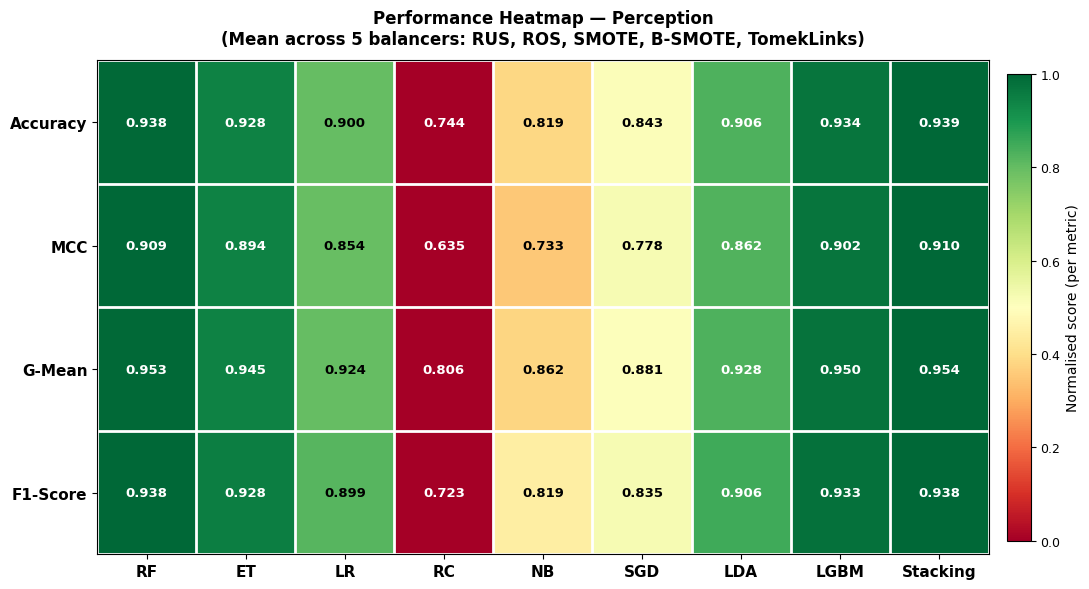

✓ Saved: heatmap_Perception.png


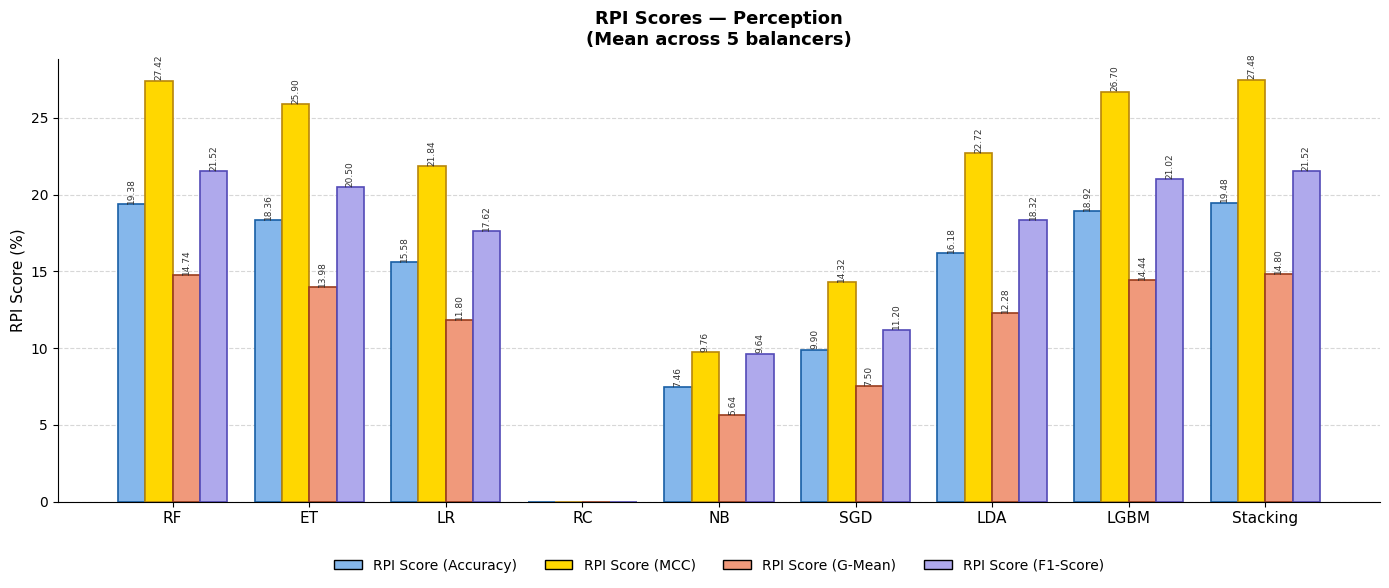

✓ Saved: rpi_Perception.png

[Perception]
  Friedman χ² = 37.4891,  p = 0.000009
  CD = 4.7181  (Nemenyi α=0.05, k=9, N=5)


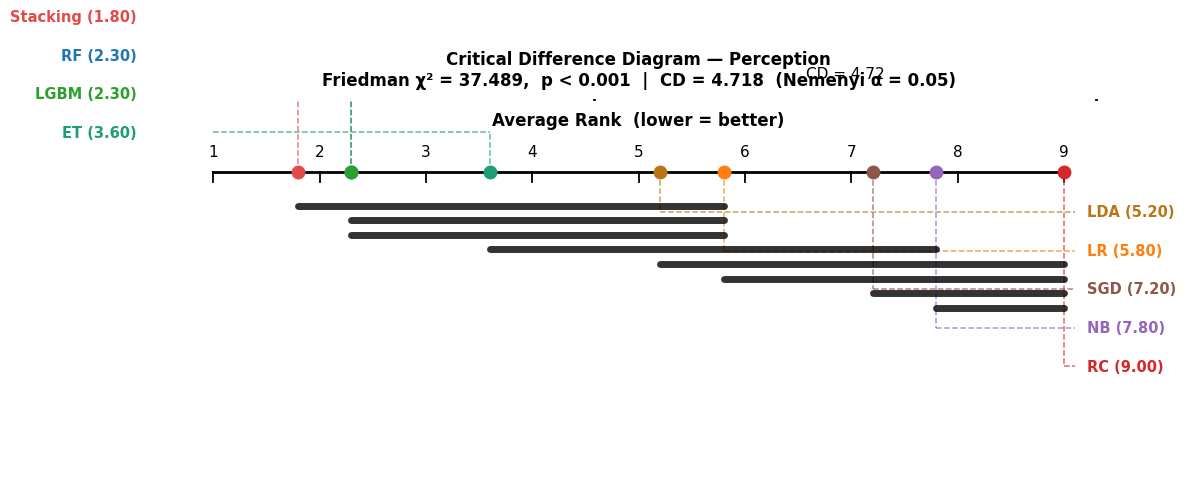

✓ Saved: cd_diagram_Perception.png


In [ ]:
print("=" * 50)
print("   EXPERIMENT: PERCEPTION")
print("=" * 50)
plot_heatmap(perception_raw, 'Perception')
plot_rpi(perception_raw, 'Perception')
plot_cd_diagram(perception_raw, 'Perception')

   EXPERIMENT: EXPECTATION


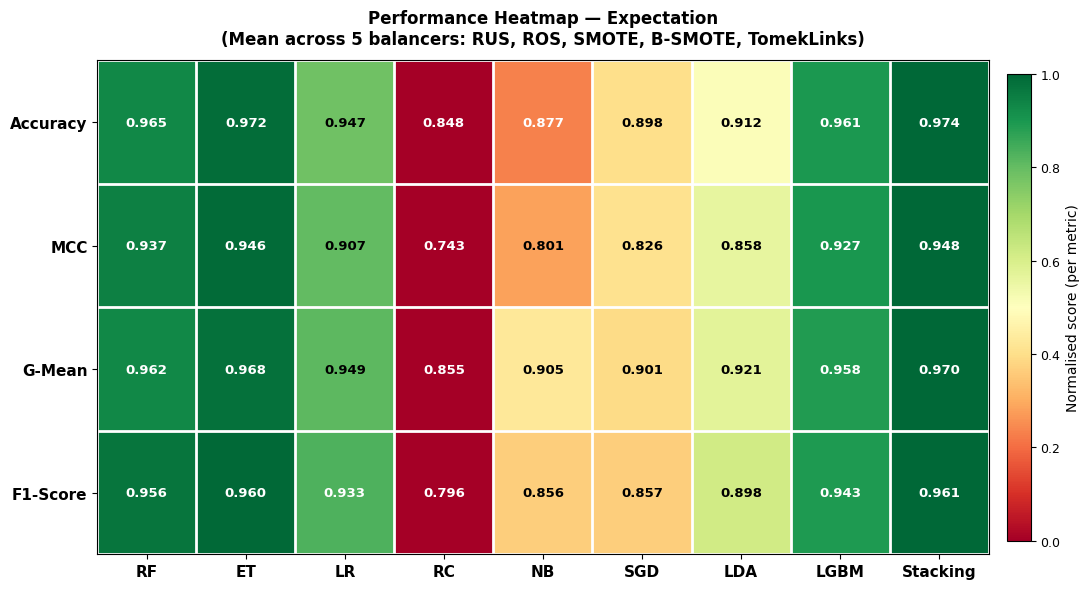

✓ Saved: heatmap_Expectation.png


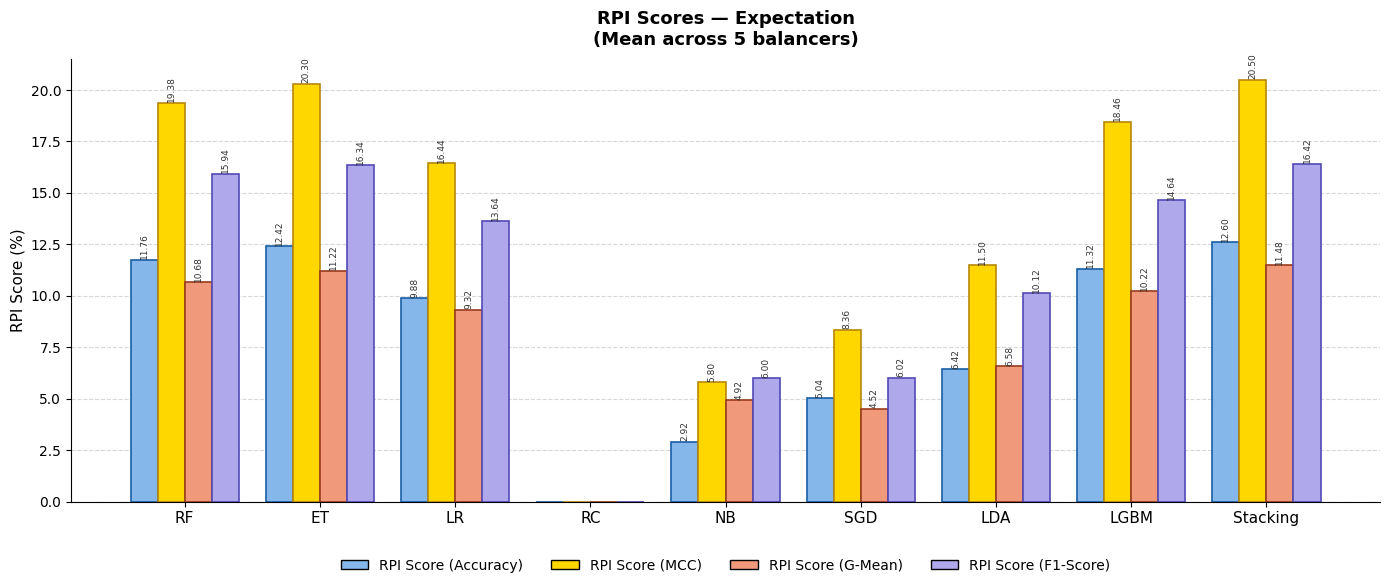

✓ Saved: rpi_Expectation.png

[Expectation]
  Friedman χ² = 33.4874,  p = 0.000050
  CD = 4.7181  (Nemenyi α=0.05, k=9, N=5)


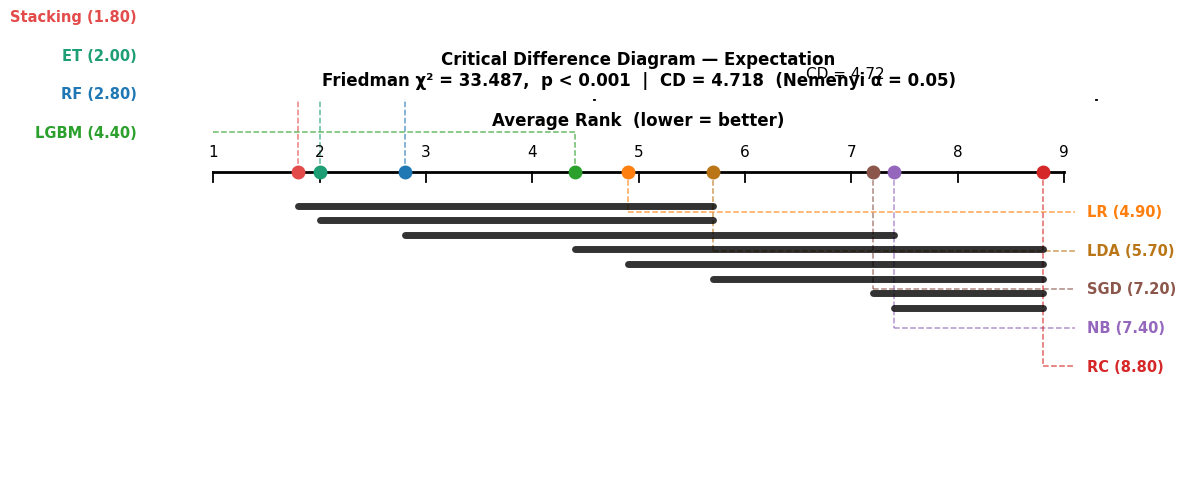

✓ Saved: cd_diagram_Expectation.png


In [ ]:
print("=" * 50)
print("   EXPERIMENT: EXPECTATION")
print("=" * 50)
plot_heatmap(expectation_raw, 'Expectation')
plot_rpi(expectation_raw, 'Expectation')
plot_cd_diagram(expectation_raw, 'Expectation')

   EXPERIMENT: GAP


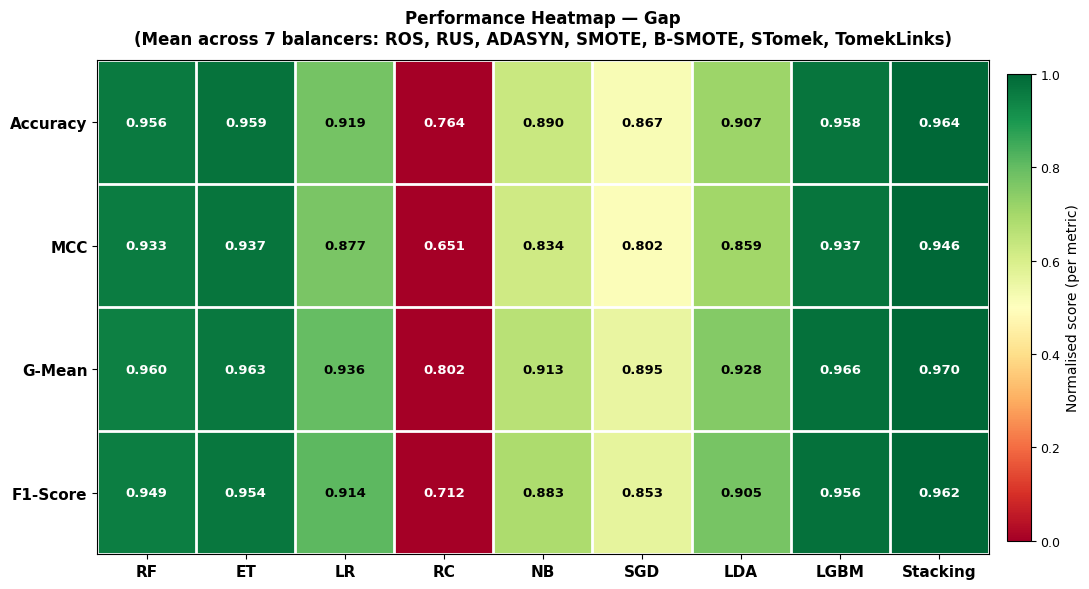

✓ Saved: heatmap_Gap.png


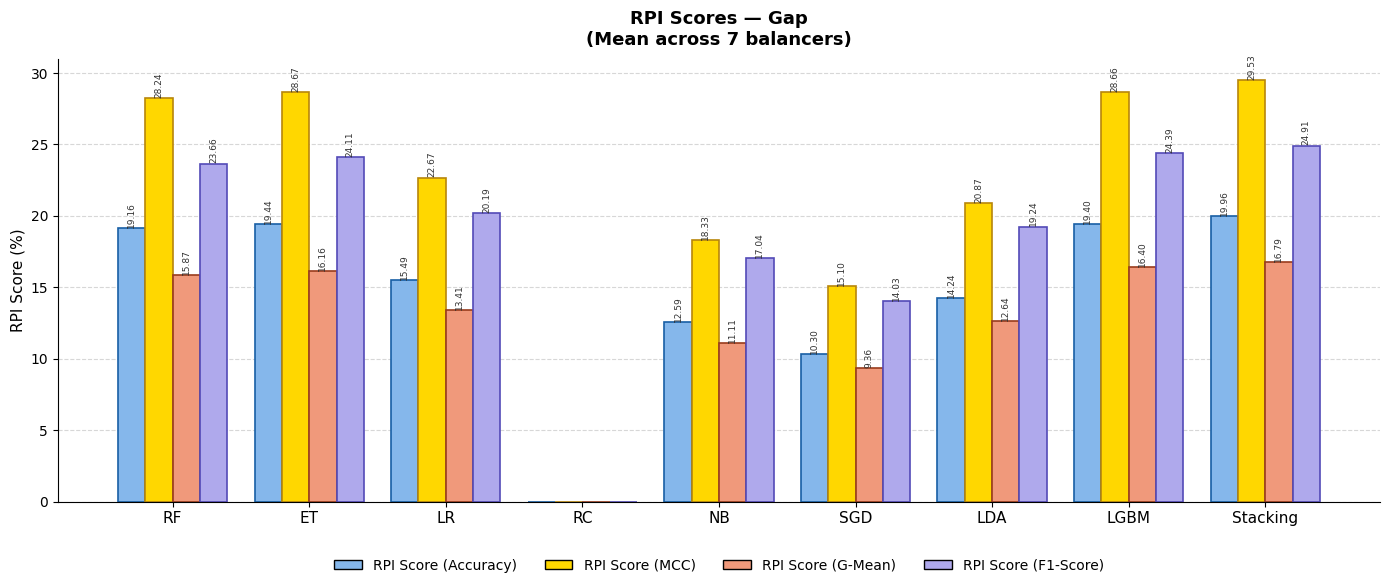

✓ Saved: rpi_Gap.png

[Gap]
  Friedman χ² = 52.6180,  p = 0.000000
  CD = 3.9875  (Nemenyi α=0.05, k=9, N=7)


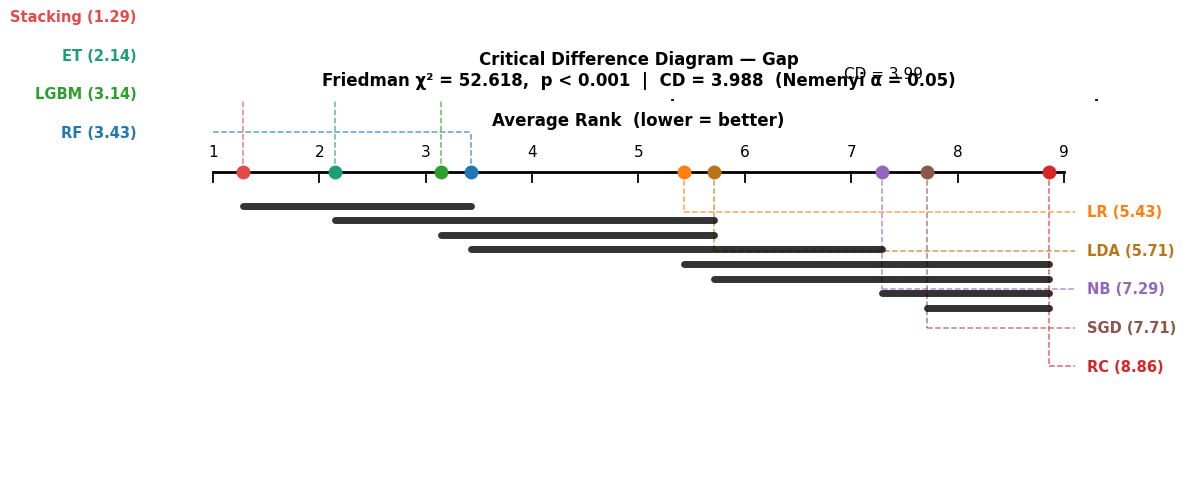

✓ Saved: cd_diagram_Gap.png


In [ ]:
print("=" * 50)
print("   EXPERIMENT: GAP")
print("=" * 50)
plot_heatmap(gap_raw, 'Gap')
plot_rpi(gap_raw, 'Gap')
plot_cd_diagram(gap_raw, 'Gap')